In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

np.random.seed(5)

city = "Дніпро"

monthly_temp = [
    -4, -3, 3, 11, 17, 21,
    23, 22, 16, 9, 3, -2
]

months = [
    "Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
    "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"
]

rows = []

for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0, 30
    )
    heating_days = round(heating_days)

    cost = (
        0.15 * heating_days
        + np.random.normal(0, 1.0)
    )
    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

climate

,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Дніпро,Січ,-4,23,3.1
1,Дніпро,Лют,-3,25,3.5
2,Дніпро,Бер,3,15,3.8
3,Дніпро,Кві,11,6,0.3
4,Дніпро,Тра,17,1,0.0
5,Дніпро,Чер,21,0,0.0
6,Дніпро,Лип,23,0,0.6
7,Дніпро,Сер,22,0,0.0
8,Дніпро,Вер,16,4,2.5
9,Дніпро,Жов,9,7,1.7


In [2]:
x = climate["температура"]
y = climate["витрати_на_опалення"]

result = linregress(x, y)

print("slope =", result.slope)
print("intercept =", result.intercept)
print("r =", result.rvalue)
print("p-value =", result.pvalue)

slope = -0.11088757396449705
intercept = 2.663579881656805
r = -0.781396266904476
p-value = 0.002687750087671019


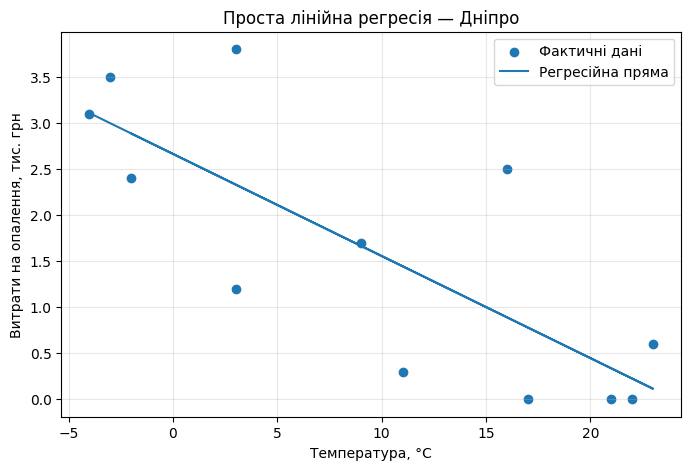

In [3]:
predicted = (
    result.intercept
    + result.slope * x
)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, label="Фактичні дані")
plt.plot(x, predicted, label="Регресійна пряма")

plt.xlabel("Температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title("Проста лінійна регресія — Дніпро")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Отримано рівняння регресії:

витрати ≈ 2.664 - 0.111 × температура.

Коефіцієнт нахилу b1 ≈ -0.111 означає, що при
збільшенні середньомісячної температури на 1 °C
очікувані витрати на опалення в середньому
зменшуються приблизно на 0.111 тис. грн,
тобто приблизно на 111 грн.

Від'ємний знак коефіцієнта є логічним: при вищій
температурі потрібно менше опалення, тому витрати
мають тенденцію зменшуватися.

Перетин b0 ≈ 2.664 означає формальне прогнозоване
значення витрат при температурі 0 °C.

In [4]:
r_squared_1 = result.rvalue ** 2

print("R² через rvalue =", r_squared_1)

R² через rvalue = 0.610580125932251


In [5]:
residuals = y - predicted

ss_res = np.sum(residuals ** 2)

ss_total = np.sum(
    (y - y.mean()) ** 2
)

r_squared_2 = 1 - ss_res / ss_total

print("SS залишків =", ss_res)
print("SS загальна =", ss_total)
print("R² вручну =", r_squared_2)

SS залишків = 8.835612426035501
SS загальна = 22.68916666666667
R² вручну = 0.610580125932251


In [6]:
print("R² через rvalue:", r_squared_1)
print("R² вручну:", r_squared_2)

print(
    "Чи збігаються?",
    np.isclose(r_squared_1, r_squared_2)
)

R² через rvalue: 0.610580125932251
R² вручну: 0.610580125932251
Чи збігаються? True


In [7]:
r, p = pearsonr(x, y)

print("r Пірсона =", r)
print("r² =", r ** 2)
print("R² =", r_squared_1)

r Пірсона = -0.7813962669044758
r² = 0.6105801259322509
R² = 0.610580125932251


Коефіцієнт детермінації становить:

R² ≈ 0.611.

Отже, приблизно 61.1% розкиду витрат на опалення
в цьому наборі пояснюється їх лінійним зв'язком
із середньомісячною температурою.

Приблизно 38.9% розкиду залишається непоясненим
цією простою моделлю та може бути пов'язано з іншими
факторами і випадковим шумом.

R², обчислений через result.rvalue ** 2, та R²,
обчислений вручну через суми квадратів, збігаються.

Також R² = r² для простої лінійної регресії.

In [8]:
climate["прогноз"] = predicted
climate["залишок"] = residuals

climate[
    [
        "місяць",
        "температура",
        "витрати_на_опалення",
        "прогноз",
        "залишок"
    ]
]

,місяць,температура,витрати_на_опалення,прогноз,залишок
0,Січ,-4,3.1,3.107130,-0.007130
1,Лют,-3,3.5,2.996243,0.503757
2,Бер,3,3.8,2.330917,1.469083
3,Кві,11,0.3,1.443817,-1.143817
4,Тра,17,0.0,0.778491,-0.778491
5,Чер,21,0.0,0.334941,-0.334941
6,Лип,23,0.6,0.113166,0.486834
7,Сер,22,0.0,0.224053,-0.224053
8,Вер,16,2.5,0.889379,1.610621
9,Жов,9,1.7,1.665592,0.034408


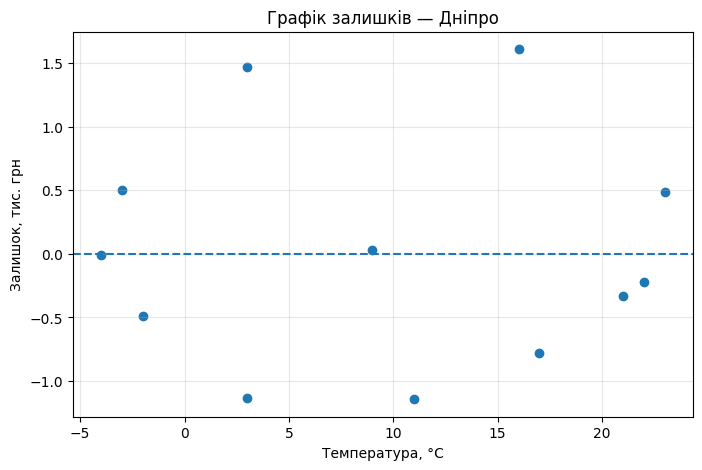

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    climate["температура"],
    climate["залишок"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Температура, °C")
plt.ylabel("Залишок, тис. грн")
plt.title("Графік залишків — Дніпро")

plt.grid(alpha=0.3)
plt.show()

Залишки розташовані по обидва боки від нуля, але
вони не утворюють абсолютно рівномірної випадкової
хмари.

Наприклад, при температурі 16 °C спостерігається
помітний додатний залишок близько +1.61 тис. грн,
а при 11 °C — від'ємний залишок близько -1.14 тис. грн.

Для найтепліших місяців із температурами приблизно
17–23 °C модель також має особливість: фактичні витрати
часто дорівнюють або близькі до нуля.

Причиною може бути спосіб генерації даних:
витрати штучно обмежені знизу нулем за допомогою
max(cost, 0).

Лінійна регресійна пряма такого обмеження не має
і теоретично може продовжувати зменшувати прогнозовані
витрати нижче нуля.

Через це для теплих місяців у залишках може виникати
структура, яку проста лінійна модель повністю не враховує.

Таким чином, R² ≈ 0.611 показує помітну пояснювальну
здатність моделі, але сам по собі не гарантує,
що лінійна модель ідеально описує залежність.

In [10]:
new_temp = -10

predicted_cost = (
    result.intercept
    + result.slope * new_temp
)

print(
    "Прогноз при -10°C:",
    predicted_cost,
    "тис. грн"
)

print(
    "Діапазон температур:",
    x.min(),
    "до",
    x.max()
)

Прогноз при -10°C: 3.7724556213017753 тис. грн
Діапазон температур: -4 до 23


За рівнянням регресії прогнозовані витрати на опалення
при температурі -10 °C становлять приблизно
3.77 тис. грн.

Фактичний діапазон температур у наборі Дніпра:

від -4 °C до 23 °C.

Температура -10 °C знаходиться за межами цього
діапазону, тому це екстраполяція.

До такого прогнозу слід ставитися обережніше, ніж
до прогнозу для температури всередині діапазону
[-4; 23] °C.

Модель була побудована лише за наявними спостереженнями
і не перевірена на температурах нижче -4 °C.

За межами спостережених даних залежність може
змінитися, тому лінійне продовження не обов'язково
залишається правильним.

In [11]:
r, pearson_p = pearsonr(x, y)

print(
    "p-value linregress:",
    result.pvalue
)

print(
    "p-value pearsonr:",
    pearson_p
)

print(
    "r Пірсона:",
    r
)

p-value linregress: 0.002687750087671019
p-value pearsonr: 0.002687750087671028
r Пірсона: -0.7813962669044758


p-value з linregress() та pearsonr() практично
повністю збігаються:

p ≈ 0.00269.

Причина полягає в тому, що у простій лінійній регресії
з одним предиктором перевірка гіпотези

H₀: b1 = 0

про нульовий нахил регресійної прямої еквівалентна
перевірці гіпотези

H₀: r = 0

про відсутність лінійної кореляції.

Якщо лінійного зв'язку немає, нахил регресійної прямої
дорівнює нулю і коефіцієнт Пірсона також дорівнює нулю.

Оскільки p ≈ 0.00269 < 0.05, маємо статистично
значущий лінійний зв'язок між температурою
та витратами на опалення.

1. Чому метод найменших квадратів мінімізує саме
суму квадратів залишків?

Якби використовувалася проста сума залишків, додатні
та від'ємні помилки могли б взаємно компенсуватися.

Піднесення до квадрата робить усі внески додатними
та сильніше штрафує великі помилки.

Крім того, сума квадратів має зручні математичні
властивості, що дозволяють однозначно знаходити
коефіцієнти лінійної регресії.

Сума модулів також може використовуватися в інших
методах, але вона приводить до іншої моделі
оцінювання і складнішої оптимізації.


2. Що означає коефіцієнт b1 і чим він відрізняється
від коефіцієнта кореляції r?

Для нашої моделі b1 ≈ -0.111.

Це означає, що при збільшенні температури на 1 °C
очікувані витрати на опалення в середньому
зменшуються приблизно на 0.111 тис. грн.

b1 має конкретні одиниці вимірювання:
тис. грн на 1 °C.

Коефіцієнт кореляції r ≈ -0.781 не має одиниць.
Він показує напрямок та силу лінійного зв'язку,
але безпосередньо не говорить, на скільки гривень
зміняться витрати при зміні температури на 1 °C.


3. Чому високий R² не гарантує адекватності моделі?

R² показує, яку частку розкиду залежної змінної
пояснює модель, але не показує форму помилок.

Навіть при високому R² у залишках може бути
систематична структура, нелінійність, зміна розкиду
або окремі викиди.

Графік залишків дозволяє побачити такі проблеми.

У нашому випадку додатковою проблемою є те, що
витрати не можуть бути нижчими за нуль, тоді як
звичайна лінійна модель такого обмеження не має.

Тому аналізувати потрібно не лише R², а й залишки.


4. Що відбувається з надійністю прогнозу при
виході x за межі спостереженого діапазону?

Такий прогноз називається екстраполяцією.

Його надійність знижується, оскільки модель не була
перевірена на спостереженнях у цій області.

Наприклад, у нашому наборі температури лежать
у діапазоні від -4 °C до 23 °C.

Прогноз для -10 °C виходить за межі цього діапазону.
Ми лише припускаємо, що встановлена лінійна залежність
продовжується далі, хоча фактичних даних для
підтвердження цього немає.